In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
# standardScaler is used to standardize the features by removing the mean and scaling to unit variance
# labelencodeer is used to convert categorical labels into numerical labels
from sklearn.preprocessing import StandardScaler , LabelEncoder
# here perceptron is used to create a linear classifier for binary classification problems

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
# here sequential is used to create a linear stack of layers for the neural network model
from tensorflow.keras.models import Sequential
# dense mean every neuron in the layer is connected to every neuron in the previous layer
# here dropout is used to prevent overfitting by randomly setting a fraction of input units to 0 at each update during training time
from tensorflow.keras.layers import Dense , Dropout
# here to_categorical is used to convert class vectors (integers) to binary class matrices for multi-class classification problems
# like one-hot encoding
from tensorflow.keras.utils import to_categorical

In [25]:
df = pd.read_csv('Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [26]:
df.count()

Id               150
SepalLengthCm    150
SepalWidthCm     150
PetalLengthCm    150
PetalWidthCm     150
Species          150
dtype: int64

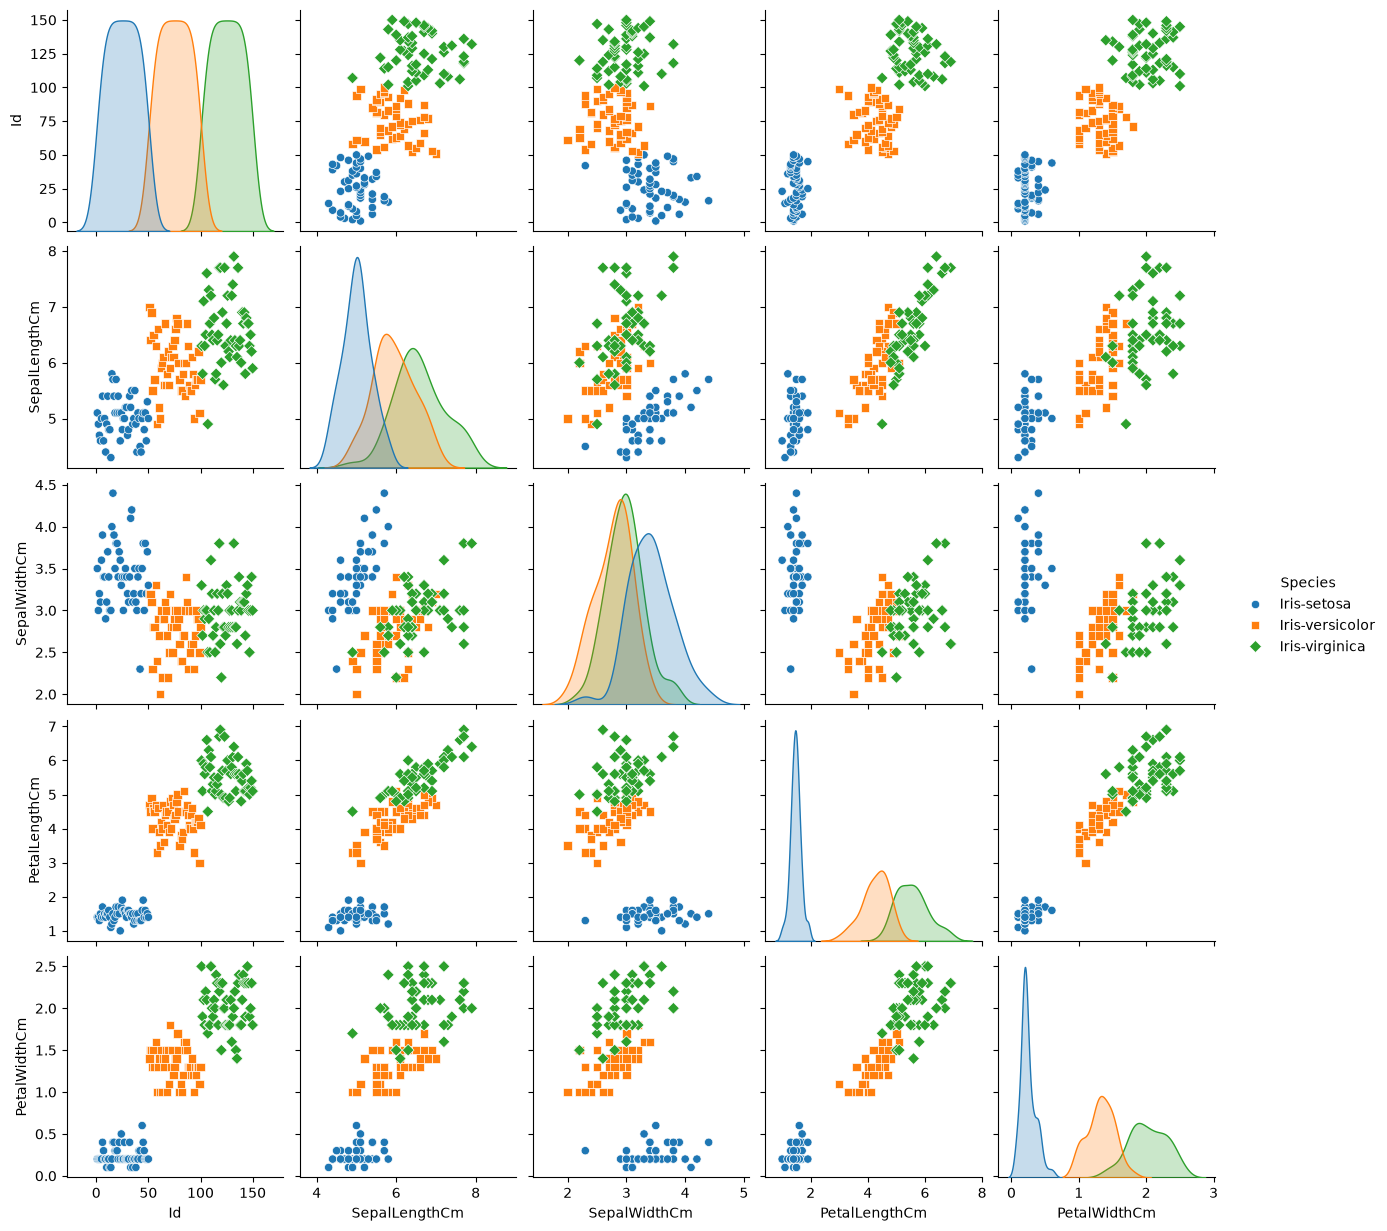

In [27]:
sns.pairplot(df, hue='Species', markers=["o", "s", "D"])

In [28]:
X = df.drop(['Id', 'Species'], axis=1)


In [29]:
encoder = LabelEncoder()
y_new = encoder.fit_transform(df['Species'])
y_new

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y_new, test_size=0.2, random_state=42 , stratify=y_new)
# stratify=y_new is used to ensure that the class distribution in the train and test sets is similar to the original dataset.

In [31]:
scaler = StandardScaler()
X_train_S = scaler.fit_transform(X_train)
X_test_S = scaler.transform(X_test)

In [32]:
per = Perceptron(max_iter=1000, random_state=42)
per.fit(X_train_S, y_train)

,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None


In [33]:
y_pred_per = per.predict(X_test_S)
# doing this to check the accuracy of the model on the test set
accuracy_per = accuracy_score(y_test, y_pred_per)
accuracy_per

0.8666666666666667

In [34]:
print("Accuracy of Perceptron Model:", accuracy_per)
print("Classification Report for Perceptron Model:\n", classification_report(y_test, y_pred_per))

Accuracy of Perceptron Model: 0.8666666666666667
Classification Report for Perceptron Model:
               precision    recall  f1-score   support

           0       0.83      1.00      0.91        10
           1       0.88      0.70      0.78        10
           2       0.90      0.90      0.90        10

    accuracy                           0.87        30
   macro avg       0.87      0.87      0.86        30
weighted avg       0.87      0.87      0.86        30



###  Now throough ANN

In [35]:
y_train_cat = to_categorical(y_train , num_classes=3)
y_test_cat = to_categorical(y_test , num_classes=3)
y_train_cat


array([[1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0

In [42]:
model = Sequential([
    Dense(16, input_dim =4 , activation='relu'),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

In [43]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [44]:
history = model.fit(X_train_S, y_train_cat, epochs=100, batch_size=4, validation_split=0.2 , verbose=1)

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1562 - loss: 1.1381 - val_accuracy: 0.5417 - val_loss: 1.0842
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6771 - loss: 0.9843 - val_accuracy: 0.5833 - val_loss: 0.9624
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8021 - loss: 0.8511 - val_accuracy: 0.7083 - val_loss: 0.8396
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8542 - loss: 0.7197 - val_accuracy: 0.7083 - val_loss: 0.7135
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8542 - loss: 0.5947 - val_accuracy: 0.7083 - val_loss: 0.6044
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8542 - loss: 0.4949 - val_accuracy: 0.7917 - val_loss: 0.5270
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8438 - loss: 0.4290 - val_accuracy: 0.7917 - val_loss: 0.4691
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8542 - loss: 0.3850 - val_accuracy: 0.7917 - v

In [46]:
loss , accuracy = model.evaluate(X_test_S, y_test_cat , verbose=1)
print("Loss of ANN Model:", loss)
print("Accuracy of ANN Model:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9667 - loss: 0.0906
Loss of ANN Model: 0.090559221804142
Accuracy of ANN Model: 0.9666666388511658


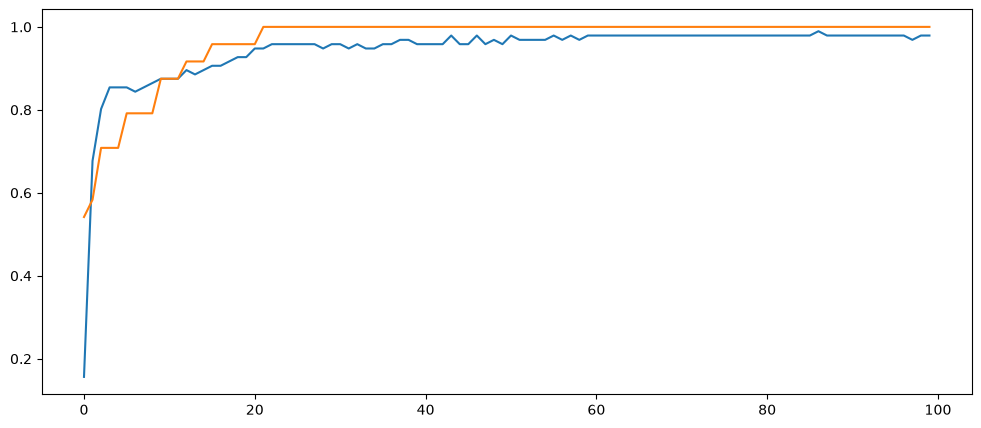

In [49]:
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')